In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
df = pd.read_csv("customer-reviews-1000.csv")

df.head()

,Index,Review ID,Product Name,Rating,Review Text
0,1,qMFYtF68SE,Mini Drone Speaker Speaker,5,Support answered quickly in a small office. I ...
1,2,UiElzuHDqZ,Smart Thermostat Camera Watch,2,Support took too long to answer for daily work...
2,3,R8YYLs7LHp,Tablet Speakerphone,1,The product stopped working after a few days f...
3,4,tNRUqxp4PX,Mouse Heater,1,The first impression was disappointing while t...
4,5,VQ5KyI6raO,Dock,4,The build quality feels solid after a month of...


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 5)

Columns:
['Index', 'Review ID', 'Product Name', 'Rating', 'Review Text']

Missing Values:
Index           0
Review ID       0
Product Name    0
Rating          0
Review Text     0
dtype: int64


In [5]:
df = df[["Review Text", "Rating"]].copy()

df.head()

,Review Text,Rating
0,Support answered quickly in a small office. I ...,5
1,Support took too long to answer for daily work...,2
2,The product stopped working after a few days f...,1
3,The first impression was disappointing while t...,1
4,The build quality feels solid after a month of...,4


In [6]:
df = df.dropna(subset=["Review Text", "Rating"])

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (1000, 2)


In [8]:
def create_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Rating"].apply(create_sentiment)

df.head()

,Review Text,Rating,Sentiment
0,Support answered quickly in a small office. I ...,5,Positive
1,Support took too long to answer for daily work...,2,Negative
2,The product stopped working after a few days f...,1,Negative
3,The first impression was disappointing while t...,1,Negative
4,The build quality feels solid after a month of...,4,Positive


Sentiment
Positive    345
Negative    338
Neutral     317
Name: count, dtype: int64


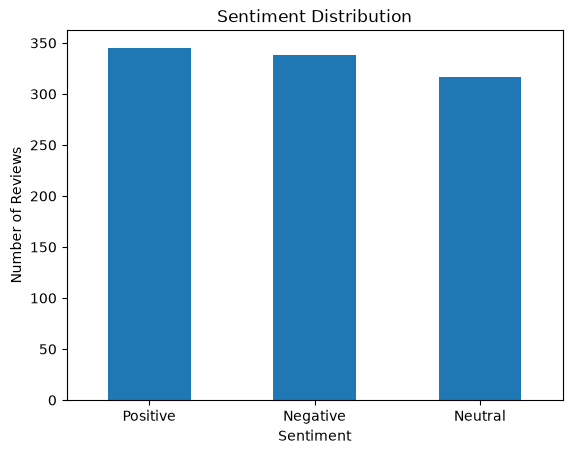

In [9]:
print(df["Sentiment"].value_counts())

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [10]:
X = df["Review Text"]
y = df["Sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000,)
y shape: (1000,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [12]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train TF-IDF shape:", X_train_tfidf.shape)
print("X_test TF-IDF shape:", X_test_tfidf.shape)

X_train TF-IDF shape: (800, 225)
X_test TF-IDF shape: (200, 225)


In [14]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [15]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully.")
print(y_pred[:10])

Predictions generated successfully.
['Negative' 'Positive' 'Neutral' 'Neutral' 'Positive' 'Neutral' 'Positive'
 'Negative' 'Negative' 'Negative']


In [16]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 1.0000
Test Accuracy: 100.00%


In [17]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Neutral", "Positive"]
    )
)

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        68
     Neutral       1.00      1.00      1.00        63
    Positive       1.00      1.00      1.00        69

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



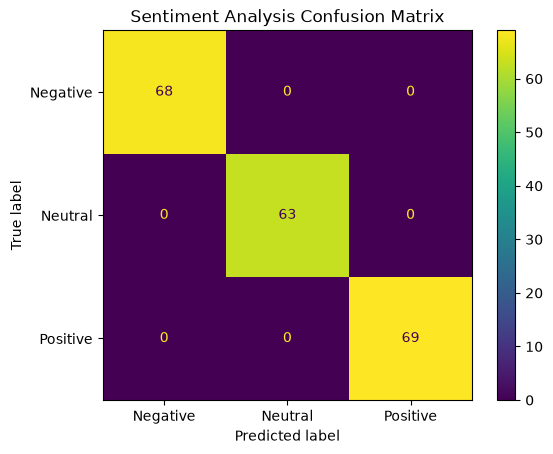

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Negative", "Neutral", "Positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()

plt.title("Sentiment Analysis Confusion Matrix")
plt.show()

In [19]:
new_reviews = [
    "The product is excellent and works perfectly.",
    "The product stopped working and I am very disappointed.",
    "The product is okay but could be improved."
]

new_reviews_tfidf = tfidf.transform(new_reviews)

predictions = model.predict(new_reviews_tfidf)

for review, sentiment in zip(new_reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 50)

Review: The product is excellent and works perfectly.
Predicted Sentiment: Neutral
--------------------------------------------------
Review: The product stopped working and I am very disappointed.
Predicted Sentiment: Negative
--------------------------------------------------
Review: The product is okay but could be improved.
Predicted Sentiment: Neutral
--------------------------------------------------


In [20]:
print("========== DAY 14 FINAL CHECK ==========")
print("Dataset Shape:", df.shape)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("TF-IDF Features:", X_train_tfidf.shape[1])
print("Model:", type(model).__name__)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("\nSentiment Classes:")
print(y.value_counts())

========== DAY 14 FINAL CHECK ==========
Dataset Shape: (1000, 3)
Training Samples: 800
Testing Samples: 200
TF-IDF Features: 225
Model: LogisticRegression
Test Accuracy: 100.00%

Sentiment Classes:
Sentiment
Positive    345
Negative    338
Neutral     317
Name: count, dtype: int64


In [1]:
from transformers import pipeline

In [2]:
import re

def clean_text(text):
    text = re.sub(r"<.*?>", " ", str(text))      # Remove HTML tags
    text = re.sub(r"[^\x00-\x7F]+", " ", text)  # Remove non-ASCII characters
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'-]", " ", text)  # Remove unwanted characters
    text = re.sub(r"\s+", " ", text)             # Remove extra spaces
    return text.strip()

In [ ]:
df = pd.read_csv("customer-reviews-1000.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

NameError: name 'pd' is not defined